# CycleTrack :  Free-to-Premium Conversion Analysis

## The Problem
CycleTrack is a freemium women's health app with 15,000 registered users across six markets. 
The product team reported an overall free-to-premium conversion rate of 11% .
The Growth team wanted three things answered:

1. **Is the 11% conversion rate telling the full story?** Or is it masking meaningfully 
   different behaviour across user segments?
2. **If underperforming segments exist, what's causing it?** Is it a product problem, 
   a targeting problem, or something else?
3. **What should the team do about it and how would we know it's working?** A specific 
   intervention, an experiment design, and a way to read out results faster than waiting 
   60 days for enough subscription events to accumulate.


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# load datasets
users = pd.read_csv('users.csv', parse_dates=['signup_date', 'conversion_date'])
activity = pd.read_csv('daily_activity.csv', parse_dates=['activity_date'])
paywall  = pd.read_csv('paywall_events.csv', parse_dates=['event_date'])


print(f"users         : {len(users):,} rows")
print(f"daily_activity: {len(activity):,} rows")
print(f"paywall_events: {len(paywall):,} rows")

users.head(10)

users         : 15,000 rows
daily_activity: 1,350,000 rows
paywall_events: 44,448 rows


,user_id,signup_date,country,age_band,acquisition_channel,device,cycle_stage_at_signup,engagement_segment,premium_status,conversion_date,days_to_conversion
0,u_xaji0y6d,2023-07-08,US,25-34,paid_search,Android,tracking,tracker,free,NaT,NaN
1,u_pbhsahxt,2024-03-30,UK,18-24,paid_social,iOS,tracking,passive,free,NaT,NaN
2,u_hv3a3zmf,2024-06-25,US,25-34,paid_search,iOS,postpartum,passive,free,NaT,NaN
3,u_8mdd4v30,2024-05-31,US,35-44,referral,iOS,tracking,insights,free,NaT,NaN
4,u_t9nt3w5u,2023-12-26,BR,18-24,paid_social,iOS,tracking,tracker,premium,2024-01-13,18.0
5,u_zbikcidk,2024-01-04,IN,25-34,organic,iOS,trying_to_conceive,tracker,premium,2024-01-15,11.0
6,u_wnnhj7xv,2023-07-19,US,35-44,referral,Android,tracking,tracker,free,NaT,NaN
7,u_g0fn9xuy,2023-01-07,US,35-44,paid_search,Android,tracking,passive,free,NaT,NaN
8,u_41ibljh7,2024-01-21,US,45+,organic,iOS,tracking,insights,free,NaT,NaN
9,u_5lxo6qji,2024-01-31,IN,35-44,referral,iOS,tracking,passive,free,NaT,NaN


In [18]:
premium_conv_rate = (users['premium_status']=='premium').mean()
premium_users = (users['premium_status'] == 'premium').sum()
total_users = len(users)
print(f"Total users    : {total_users:,}")
print(f"Premium users  : {premium_users:,}")
print(f"Conversion rate: {premium_conv_rate:.1%}")

Total users    : 15,000
Premium users  : 1,656
Conversion rate: 11.0%


**11% overall conversion.**

A note on the denominator: every user in this dataset starts as a free user there is no 
direct-to-premium signup path.  
All users also had a minimum 60-day observation window before the dataset cutoff, so we are not undercounting conversion by including users who signed up too recently to have had a fair chance to convert.

## Observation 1 : Overall 11 % conversion to premium .
**But is this number uniform across users or is it averaging over very different behaviour?**

Classifing users based on how they actually behaved in their first 30 days in the app. 

Two dimensions drive the classification:
- **Tracking rate**: proportion of days in first 30 where the user logged cycle or symptom data
- **Insights rate** :average number of health articles read per day in first 30 days

# Exploring User Activity

In [32]:
activity.head(10)

,user_id,activity_date,tracked_cycle,insights_read,community_visits,premium_screen_hit,premium_preview_engaged,session_duration_mins
0,u_xaji0y6d,2023-07-08,False,0,0,True,False,6.0
1,u_xaji0y6d,2023-07-09,False,0,0,True,False,6.0
2,u_xaji0y6d,2023-07-10,False,0,0,False,False,5.6
3,u_xaji0y6d,2023-07-11,True,0,0,False,False,5.6
4,u_xaji0y6d,2023-07-12,True,0,0,False,False,9.4
5,u_xaji0y6d,2023-07-13,True,0,0,False,False,6.0
6,u_xaji0y6d,2023-07-14,True,0,1,True,False,5.3
7,u_xaji0y6d,2023-07-15,False,0,0,False,False,8.4
8,u_xaji0y6d,2023-07-16,True,1,0,False,False,6.9
9,u_xaji0y6d,2023-07-17,True,1,1,False,False,2.6


In [33]:
user_dates = users[['user_id','signup_date']].copy()

#joining activity with the signup dates for each user
activity_with_signup = activity.merge(user_dates, on='user_id')

#calculate days since signup for each activity row
activity_with_signup['days_since_signup'] = (activity_with_signup['activity_date'] - activity_with_signup['signup_date']).dt.days

# Only the first 30 days
first_30 = activity_with_signup[activity_with_signup['days_since_signup'] < 30]

#calculate behaviour metrics per user
user_behaviour = (
    first_30.groupby('user_id')
            .agg(
                track_rate   =('tracked_cycle', 'mean'),
                insights_rate=('insights_read', 'mean'),
            )
            .reset_index()
)

print(user_behaviour.head())
print(f"\nUsers with behaviour data: {len(user_behaviour):,}")

      user_id  track_rate  insights_rate
0  u_000qh7d3    0.100000       0.000000
1  u_003hyieh    0.533333       0.133333
2  u_008ajhcd    0.233333       0.466667
3  u_00crz17a    0.166667       0.433333
4  u_00j90nzd    0.000000       0.000000

Users with behaviour data: 15,000


In [66]:
# step 6 — classify users into segments based on behaviour rules

def classify_user(row):
    if row['track_rate'] >= 0.5:
        return 'tracker'
    elif row['insights_rate'] >= 0.4:
        return 'insights'
    else:
        return 'passive'

user_behaviour['derived_segment'] = user_behaviour.apply(classify_user, axis=1)

print(user_behaviour['derived_segment'].value_counts())
print("\n")
print(user_behaviour.head())

passive     5920
tracker     5205
insights    3875
Name: derived_segment, dtype: int64


      user_id  track_rate  insights_rate derived_segment
0  u_000qh7d3    0.100000       0.000000         passive
1  u_003hyieh    0.533333       0.133333         tracker
2  u_008ajhcd    0.233333       0.466667        insights
3  u_00crz17a    0.166667       0.433333        insights
4  u_00j90nzd    0.000000       0.000000         passive


## Observation 2:
Passive - 5,920 users (39%)  
Low tracking, low insights reading. Largest group which makes sense, a lot of users sign up and never fully engage.  
tracker - 5,205 users (35%)  
Track on at least half of their first 30 days. Core product users.  
insights - 3,875 users (26%)  
Don't track much but read health content regularly. The underserved segment.  

In [36]:
#merge derived segment back onto users table
users = users.merge(
    user_behaviour[['user_id', 'track_rate', 'insights_rate', 'derived_segment']],
    on='user_id',
    how='left'
)

print(users[['user_id', 'engagement_segment', 'derived_segment']].head(10))

      user_id engagement_segment derived_segment
0  u_xaji0y6d            tracker         tracker
1  u_pbhsahxt            passive         passive
2  u_hv3a3zmf            passive         passive
3  u_8mdd4v30           insights        insights
4  u_t9nt3w5u            tracker         tracker
5  u_zbikcidk            tracker         tracker
6  u_wnnhj7xv            tracker         tracker
7  u_g0fn9xuy            passive         passive
8  u_41ibljh7           insights        insights
9  u_5lxo6qji            passive         passive


Each user has now been assigned a segment based purely on their observed behaviour in the first 30 days

## Conversion Rate by Derived Segment

We now calculate the free-to-premium conversion rate for each segment. 
If the 11% overall rate is masking different behaviour, we should see meaningfully different conversion rates across the three groups.

In [39]:
users['is_premium'] = (users['premium_status'] == 'premium').astype(int)

# conversion rate by derived segment
seg_summary = (
    users.groupby('derived_segment')['is_premium']
         .agg(['count', 'sum', 'mean'])
         .reset_index()
)

seg_summary.columns = ['segment', 'n_users', 'n_premium', 'conversion_rate']
seg_summary['conversion_rate_pct'] = (seg_summary['conversion_rate'] * 100).round(1)
seg_summary = seg_summary.sort_values('conversion_rate', ascending=False)

print(seg_summary[['segment', 'n_users', 'n_premium', 'conversion_rate_pct']])

    segment  n_users  n_premium  conversion_rate_pct
2   tracker     5205       1175                 22.6
0  insights     3875        238                  6.1
1   passive     5920        243                  4.1


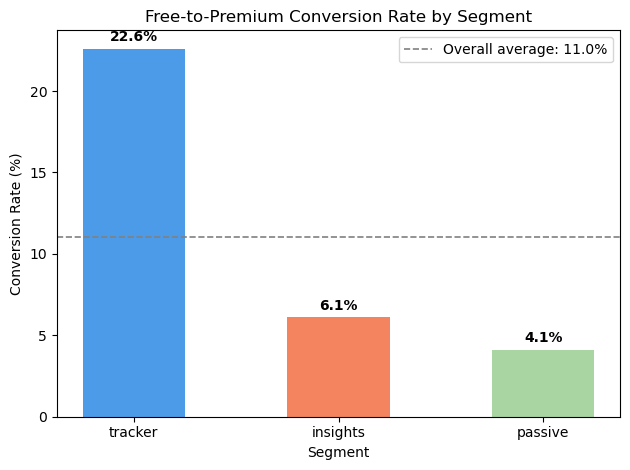

In [42]:
# visualise
fig, ax = plt.subplots()

bars = ax.bar(
    seg_summary['segment'],
    seg_summary['conversion_rate_pct'],
    color=['#4C9BE8', '#F4845F', '#A8D5A2'],
    width=0.5
)

ax.axhline(
    y=premium_conv_rate * 100,
    color='grey',
    linestyle='--',
    linewidth=1.2,
    label=f'Overall average: {premium_conv_rate:.1%}'
)

ax.set_title('Free-to-Premium Conversion Rate by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Conversion Rate (%)')
ax.legend()

for bar, val in zip(bars, seg_summary['conversion_rate_pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## Observation 3

**The 11% average is masking a 4x difference in conversion rates across segments.**

Trackers convert at over 3x the rate of insights readers, despite insights readers 
being the second largest segment in the app. 
These are not disengaged users .They are actively reading health content and spending time in the app. 
Yet fewer than 1 in 10 converts to premium.

**This is the segment worth investigating. The question is why.**

## Why Are Insights Readers Not Converting?

We know insights readers convert at 6% despite high engagement. 
The next question is why. There are three possible explanations:

1. **A paywall problem** : they are being shown the wrong upgrade prompt
2. **A supply problem**  : the premium features don't match what they actually use
3. **A timing problem** : the paywall hits them before they have experienced enough value

We investigate using the paywall_events table.

 What paywall type are insights readers seeing?

In [45]:
paywall.head(10)

,user_id,event_date,paywall_type,action
0,u_xaji0y6d,2023-07-31,feature_specific,converted
1,u_xaji0y6d,2023-08-18,feature_specific,dismissed
2,u_xaji0y6d,2023-09-02,feature_specific,dismissed
3,u_xaji0y6d,2023-10-05,feature_specific,converted
4,u_pbhsahxt,2024-04-23,generic,engaged
5,u_pbhsahxt,2024-06-04,generic,engaged
6,u_hv3a3zmf,2024-07-05,generic,engaged
7,u_8mdd4v30,2024-07-23,generic,engaged
8,u_t9nt3w5u,2023-12-31,generic,engaged
9,u_t9nt3w5u,2024-01-03,insights_specific,engaged


There are 3 paywall types :-  
    - Generic : A standard upgrade prompt that shows to all users regardless of how they use the app.   
    - feature_specific - A prompt triggered when a user tries to access a specific locked feature like advanced cycle predictions or fertility windows.   
    -insights_specific - A prompt that appears when a user tries to access premium health content articles, deep dives, personalised health reports.   

In [48]:
paywall_with_segment = paywall.merge(users[['user_id','derived_segment']],on ='user_id')

#grouping by paywall : how many times did each user saw each paywall type
paywall_dist = (
    paywall_with_segment.groupby(['derived_segment', 'paywall_type'])
                        .size()
                        .reset_index(name='n_hits')
)

# calculate total hits per segment
#Total hits means the total number of times a paywall was shown to users in that segment and paywall type combination.
segment_totals = (
    paywall_dist.groupby('derived_segment')['n_hits']
                .sum()
                .reset_index(name='total_hits')
)
    
    
paywall_dist = paywall_dist.merge(segment_totals, on='derived_segment')
paywall_dist['pct'] = (paywall_dist['n_hits'] / paywall_dist['total_hits'] * 100).round(1)
print(paywall_dist)


  derived_segment       paywall_type  n_hits  total_hits   pct
0        insights   feature_specific    1180       11731  10.1
1        insights            generic    8775       11731  74.8
2        insights  insights_specific    1776       11731  15.1
3         passive   feature_specific    4360       17532  24.9
4         passive            generic   12175       17532  69.4
5         passive  insights_specific     997       17532   5.7
6         tracker   feature_specific   12124       15185  79.8
7         tracker            generic    2324       15185  15.3
8         tracker  insights_specific     737       15185   4.9


# Observation 4
Trackers see a feature-specific paywall 80% of the time a prompt directly relevant 
to their core use case. This aligns with their 22% conversion rate.

Insights readers, by contrast, see a generic upgrade prompt 75% of the time. 
This prompt makes no connection to the health content they have been engaging with. 

One thing stands out: insights readers do encounter an insights-specific paywall 15% of the time.  
If that paywall type converts at a meaningfully higher rate, 
it would suggest the problem is not that insights readers are unwilling to pay,
it is that they are rarely being shown the right reason to.

**We now look at whether paywall type affects conversion rate.**

In [54]:
# count total hits per segment × paywall type
paywall_hits = (
    paywall_with_segment.groupby(['derived_segment', 'paywall_type'])['action']
                        .count()
                        .reset_index(name='n_hits')
)


# count conversions per segment × paywall type
paywall_converted = (
    paywall_with_segment[paywall_with_segment['action'] == 'converted']
                        .groupby(['derived_segment', 'paywall_type'])['action']
                        .count()
                        .reset_index(name='n_converted')
)

# merge and calculate conversion rate
paywall_conv = paywall_hits.merge(paywall_converted, on=['derived_segment', 'paywall_type'])
paywall_conv['conversion_rate_pct'] = (
    paywall_conv['n_converted'] / paywall_conv['n_hits'] * 100
).round(1)

print(paywall_conv)


  derived_segment       paywall_type  n_hits  n_converted  conversion_rate_pct
0        insights   feature_specific    1180           89                  7.5
1        insights            generic    8775          446                  5.1
2        insights  insights_specific    1776          337                 19.0
3         passive   feature_specific    4360          367                  8.4
4         passive            generic   12175          320                  2.6
5         passive  insights_specific     997           45                  4.5
6         tracker   feature_specific   12124         2820                 23.3
7         tracker            generic    2324          350                 15.1
8         tracker  insights_specific     737           79                 10.7


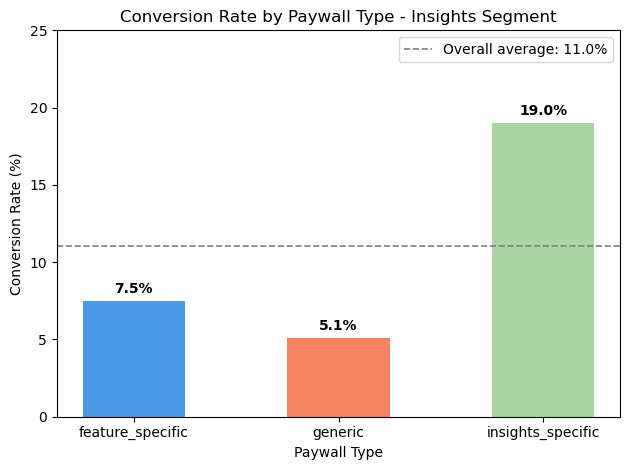

In [67]:
# filter to insights segment only
insights_paywall = paywall_conv[paywall_conv['derived_segment'] == 'insights']

fig, ax = plt.subplots()

bars = ax.bar(
    insights_paywall['paywall_type'],
    insights_paywall['conversion_rate_pct'],
    color=['#4C9BE8', '#F4845F', '#A8D5A2'],
    width=0.5
)

ax.axhline(
    y=premium_conv_rate * 100,
    color='grey',
    linestyle='--',
    linewidth=1.2,
    label=f'Overall average: {premium_conv_rate:.1%}'
)

ax.set_title('Conversion Rate by Paywall Type - Insights Segment')
ax.set_xlabel('Paywall Type')
ax.set_ylabel('Conversion Rate (%)')
ax.set_ylim(0, 25)
ax.legend()

for bar, val in zip(bars, insights_paywall['conversion_rate_pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# Observation 5

**The root cause is a paywall mismatch.**

Insights readers convert at 19% when shown an insights-specific paywall
one that surfaces premium health content directly relevant to what they 
already engage with. When shown a generic upgrade prompt, that rate drops 
to 5.1%.

This is not a demand problem. Insights readers are willing to pay for premium 
but only when the value proposition connects to their experience of the app.

The product is already doing this well for trackers: 80% of tracker paywall 
hits are feature-specific, and trackers convert at 23%. The same logic has 
simply not been extended to insights readers, who see a generic prompt 75% 
of the time.

**The fix is not to build something new. It is to show the right prompt 
to the right user.**

# Opportunity Sizing
Before proposing an intervention, we need to quantify the revenue opportunity. 
If we could shift insights readers from seeing a generic paywall 75% of the time 
to seeing an insights-specific paywall more frequently, how much incremental 
revenue would that generate?

In [56]:
# current state — insights segment
n_insights_users = len(users[users['derived_segment'] == 'insights'])
current_conv_rate = 0.051
current_premium   = round(n_insights_users * current_conv_rate)
revenue_per_user  = 48  # £3.99/month × 12

current_revenue = current_premium * revenue_per_user

print(f"Insights segment size     : {n_insights_users:,}")
print(f"Current conversion rate   : {current_conv_rate:.1%}")
print(f"Current premium users     : {current_premium:,}")
print(f"Current annual revenue    : £{current_revenue:,}")

Insights segment size     : 3,875
Current conversion rate   : 5.1%
Current premium users     : 198
Current annual revenue    : £9,504


In [58]:
# target state — if conversion lifts to 14% ( mid way between 19% (insight specific) amnd 5%(generic))
# conservative estimate: not full 19% (insights-specific rate)
# accounts for imperfect targeting and rollout

target_conv_rate = 0.14 
target_premium   = round(n_insights_users * target_conv_rate)
target_revenue   = target_premium * revenue_per_user

incremental_users   = target_premium - current_premium
incremental_revenue = target_revenue - current_revenue

print(f"Target conversion rate    : {target_conv_rate:.1%}")
print(f"Target premium users      : {target_premium:,}")
print(f"Target annual revenue     : £{target_revenue:,}")
print(f"Incremental users         : {incremental_users:,}")
print(f"Incremental annual revenue: £{incremental_revenue:,}")

Target conversion rate    : 14.0%
Target premium users      : 542
Target annual revenue     : £26,016
Incremental users         : 344
Incremental annual revenue: £16,512


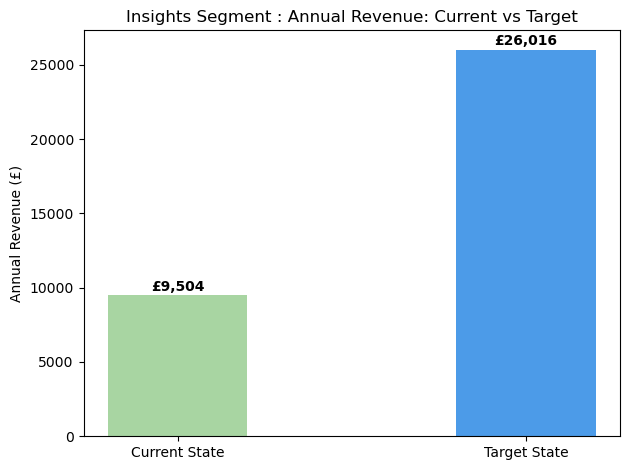

In [68]:
# visualise current vs target
fig, ax = plt.subplots()

categories = ['Current State', 'Target State']
revenues   = [current_revenue, target_revenue]
colors     = ['#A8D5A2', '#4C9BE8']

bars = ax.bar(categories, revenues, color=colors, width=0.4)

ax.set_title('Insights Segment : Annual Revenue: Current vs Target')
ax.set_ylabel('Annual Revenue (£)')

for bar, val in zip(bars, revenues):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'£{val:,}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# Observation 6
Lifting insights reader conversion from 5.1% to 14% a conservative estimate 
that does not assume every insights reader sees an insights-specific paywall 
would generate approximately £16,000 in incremental annual revenue from this 
segment alone.

The 14% target is deliberately conservative. The data shows insights readers 
convert at 19% when shown the right paywall. We apply a discount to account 
for imperfect targeting, gradual rollout, and users who have already been 
exposed to the generic prompt multiple times.

This is a back-of-envelope sizing. 

# Experiment Design


We have identified the problem, sized the opportunity, and proposed an intervention. 
The final step is to design an experiment that tells us whether the intervention works.

**The intervention:** show insights readers an insights-specific paywall instead 
of a generic one.

**The hypothesis:** personalising the paywall to surface premium health content 
relevant to what insights readers already engage with will increase their 
free-to-premium conversion rate.

### Exposed Population

We run this experiment on insights readers only - users whose first 30 days 
of behaviour classify them as insights readers using the rules defined earlier.

Running it on all users would dilute the effect. Trackers already convert well 
and are already seeing the right paywall. Including them would make it harder 
to detect a real signal in the insights segment.

### Metric Definition

**Primary metric**
Free-to-premium conversion rate for insights readers.


**Proxy metric**
Premium preview engagement rate -  whether a user clicked into a 
premium content preview before being shown the full paywall.

We use this as a proxy because it moves faster than the subscription event. 
A user who engages with a premium preview converts within 14 days at 15.8%, 
versus 1.5% for users who don't. The preview engagement signal fires on 
average 10 days before the conversion event — meaning we can detect 
whether the experiment is working 2-3 weeks earlier than waiting for 
enough subscription events to accumulate.

**Guardrail metrics**
- Overall conversion rate must not drop - we are not cannibalising other segments
- Month 1 churn rate for new premium subscribers must not increase -
  we are not converting users who immediately regret upgrading

### Power Calculation

In [61]:
import scipy.stats as stats
import math

# parameters
baseline_rate  = 0.051   # current insights conversion rate
target_rate    = 0.14    # expected conversion rate with intervention
alpha          = 0.05    # significance level
power          = 0.80    # desired power

# standard power calculation for two proportions
p1 = baseline_rate
p2 = target_rate
p_avg = (p1 + p2) / 2

z_alpha = stats.norm.ppf(1 - alpha / 2)   # two-tailed
z_beta  = stats.norm.ppf(power)

n = (
    (z_alpha * math.sqrt(2 * p_avg * (1 - p_avg)) +
     z_beta  * math.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
    / (p2 - p1) ** 2
)

n = math.ceil(n)

print(f"Baseline conversion rate : {p1:.1%}")
print(f"Target conversion rate   : {p2:.1%}")
print(f"Required sample per arm  : {n:,}")
print(f"Total sample required    : {n*2:,}")
print(f"Available insights users : {n_insights_users:,}")
print(f"Feasible                 : {n_insights_users >= n*2}")

Baseline conversion rate : 5.1%
Target conversion rate   : 14.0%
Required sample per arm  : 171
Total sample required    : 342
Available insights users : 3,875
Feasible                 : True


### Experiment Duration

In [62]:
# how long to run the experiment
daily_new_insights_users = round(n_insights_users / 24 / 30)  # users per day approx (24months data)

days_required = math.ceil((n * 2) / daily_new_insights_users)
weeks_required = math.ceil(days_required / 7)

print(f"Daily new insights users : ~{daily_new_insights_users}")
print(f"Days required            : {days_required}")
print(f"Weeks required           : {weeks_required}")

Daily new insights users : ~5
Days required            : 69
Weeks required           : 10


### Decision Criteria

| Outcome | Decision |
|---|---|
| Conversion rate lifts significantly, no guardrail breaches | Ship to all insights readers |
| Conversion rate lifts but month 1 churn increases | Investigate before shipping |
| No significant lift in conversion or proxy metric | Do not ship and revisit intervention design |
| Guardrail breach on overall conversion | Hold and check for cannibalisation |

We will read the proxy metric at week 2. If premium preview engagement 
is not lifting in the treatment group by week 2, we will consider 
stopping the experiment early rather than waiting the full duration.

### What This Experiment Does Not Tell Us

A positive result tells us that personalising the paywall for insights readers 
increases conversion. It does not tell us:

- Whether the same approach works for passive users
- Whether the effect holds over a longer time horizon
- Whether insights readers who convert have the same LTV as trackers

These are the follow-on questions for the next experiment cycle.

## Executive Summary

CycleTrack has 15,000 users and an overall free-to-premium conversion rate of 11%. 
At first glance this looks acceptable. It is not — the average is being pulled up 
by one segment and masking a significant growth opportunity.

**What we found:**

Segmenting users by their first 30 days of behaviour reveals three distinct groups. 
Trackers, users who log cycle data consistently  convert at 22%. Insights readers,  
users who engage heavily with health content but track infrequently convert at 
just 5.1% despite being the second largest segment in the app at 26% of users.

The root cause is not lack of interest in premium. When insights readers are shown 
an insights-specific paywall one that surfaces premium health content relevant to 
what they already engage with they convert at 19%. The problem is that they see 
this paywall only 15% of the time. The remaining 75% of the time they see a generic 
upgrade prompt with no connection to their experience of the app.

**What we propose:**

Show insights readers an insights-specific paywall by default. Run a controlled 
experiment on the insights segment with free-to-premium conversion as the primary 
metric and premium preview engagement rate as a proxy metric that reads out 10 days 
faster than waiting for subscription events.

**The opportunity:**

Lifting insights reader conversion from 5.1% to 14%  a conservative estimate 
generates approximately £16,000 in incremental annual revenue from this segment alone.

**Experiment duration:** 10 weeks  
**Required sample:** split insights readers 50/50 into control and treatment  
**Read proxy metric at:** week 2  
**Decision:** ship if conversion lifts significantly with no guardrail breaches